# Đề tài: Xây dựng mô hình Học máy dự đoán nguy cơ trầm cảm ở sinh viên dựa trên các yếu tố áp lực học tập và lối sống.

# Import thư viện, đọc file

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/[Học Máy]/Student_depression_dataset (1).csv')
data.head(2)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,39488,Female,21.0,Ludhiana,Student,4.0,0.0,5.68,5.0,0.0,'7-8 hours',Moderate,MCA,Yes,6.0,3.0,No,1
1,27871,Female,28.0,Jaipur,Student,3.0,0.0,5.80,3.0,0.0,'Less than 5 hours',Healthy,BHM,No,6.0,5.0,No,0


# KHÁM PHÁ DỮ LIỆU

### Kiểm tra dl

In [ ]:
df = data.copy()

In [ ]:
df.shape

(28020, 18)

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28020 entries, 0 to 28019
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28020 non-null  int64  
 1   Gender                                 28020 non-null  object 
 2   Age                                    28020 non-null  float64
 3   City                                   28020 non-null  object 
 4   Profession                             28020 non-null  object 
 5   Academic Pressure                      28018 non-null  float64
 6   Work Pressure                          28017 non-null  float64
 7   CGPA                                   28020 non-null  float64
 8   Study Satisfaction                     28019 non-null  float64
 9   Job Satisfaction                       28020 non-null  float64
 10  Sleep Duration                         28020 non-null  object 
 11  Di

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,2
Work Pressure,3
CGPA,0
Study Satisfaction,1
Job Satisfaction,0


In [ ]:
df.duplicated().value_counts() # => có 42 dòng bị trùng

,count
False,27978
True,42


In [ ]:
# Lọc lấy những dòng có ít nhất 1 ô bị thiếu (NaN)
missing_rows = df[df.isnull().any(axis=1)]
print(len(missing_rows))

6


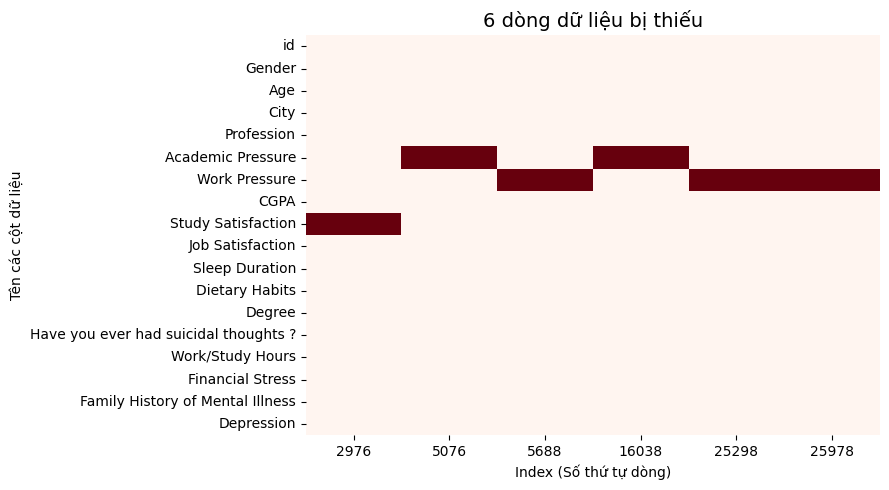

In [ ]:
# Vẽ Heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(missing_rows.isnull().T, cbar=False, xticklabels=True, yticklabels=True, cmap='Reds')
plt.title(f'{len(missing_rows)} dòng dữ liệu bị thiếu', fontsize=14)
plt.xlabel('Index (Số thứ tự dòng)')
plt.ylabel('Tên các cột dữ liệu')
plt.tight_layout()
plt.show()

In [ ]:
print(df.iloc[2976])

id                                                     35513
Gender                                                  Male
Age                                                     24.0
City                                                  Nagpur
Profession                                           Student
Academic Pressure                                        4.0
Work Pressure                                            0.0
CGPA                                                    7.08
Study Satisfaction                                       NaN
Job Satisfaction                                         0.0
Sleep Duration                           'More than 8 hours'
Dietary Habits                                     Unhealthy
Degree                                                   LLB
Have you ever had suicidal thoughts ?                    Yes
Work/Study Hours                                        11.0
Financial Stress                                         2.0
Family History of Mental

In [ ]:
print(df[['Age', 'CGPA']].describe())

                Age          CGPA
count  28020.000000  28020.000000
mean      25.789650      7.660438
std        4.997105      1.472875
min       -7.000000      0.000000
25%       21.000000      6.290000
50%       25.000000      7.770000
75%       30.000000      8.930000
max       59.000000     10.410000


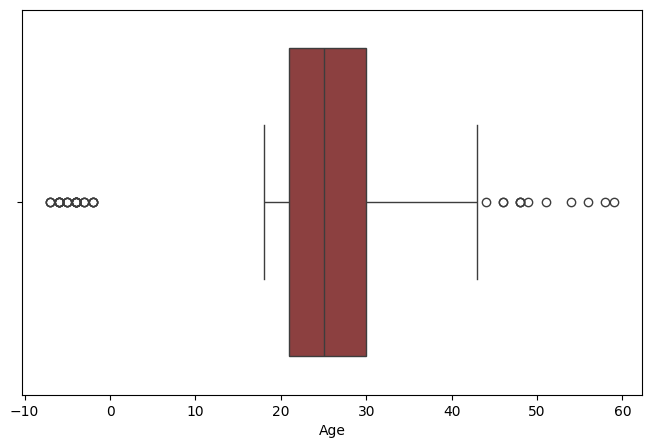

In [ ]:
# Outlier - Tuổi
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'], color='#993333')
plt.xlabel('Age')
plt.show()

In [ ]:
print(df[df['Age']<0]['Age'])   # Có 28 giá trị mà Age < 0
print('Tổng là: ', (df['Age'] < 0).sum())

180     -6.0
692     -3.0
989     -4.0
2416    -4.0
4149    -3.0
4565    -4.0
7031    -5.0
7319    -2.0
7738    -5.0
8462    -2.0
8978    -4.0
12828   -4.0
13397   -4.0
14183   -7.0
15217   -6.0
16292   -5.0
18375   -2.0
18504   -4.0
20537   -3.0
21474   -6.0
21816   -5.0
22543   -2.0
22829   -6.0
23582   -4.0
25155   -7.0
25942   -6.0
26218   -6.0
27819   -7.0
Name: Age, dtype: float64
Tổng là:  28


 **1. Age**

Dòng min có giá trị là -7.0 => Đây là ngoại lai

Giải pháp: Loại bỏ các dòng này.

**2. CGPA**

Dòng max có giá trị là 10.4 => gt này vượt ngưỡng cho phép

Giải pháp: Lỗi and xóa =)))

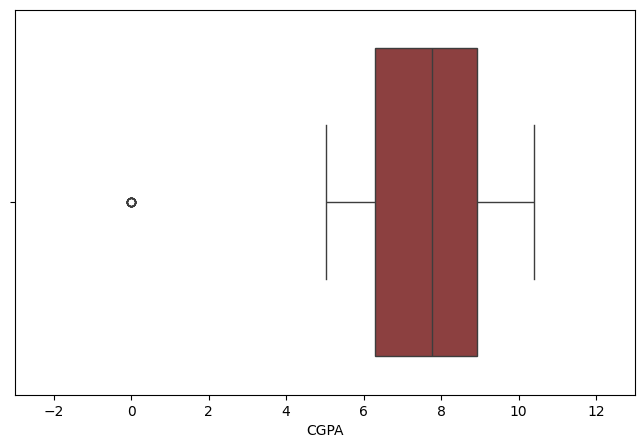

In [ ]:
# Outlier: Điểm CGPA > 10
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['CGPA'], color='#993333')
plt.xlim(-3, 13)
plt.xlabel('CGPA')
plt.show()

In [ ]:
outliers = df[df['CGPA'] > 10]['CGPA']    # Có 43 outliers > 10
print("Các giá trị CGPA ngoại lai (>10):")
print(outliers.value_counts())
print("\nTổng số outliers:", len(outliers))

Các giá trị CGPA ngoại lai (>10):
CGPA
10.12    4
10.40    3
10.24    3
10.32    3
10.19    2
10.25    2
10.41    2
10.33    2
10.39    2
10.27    2
10.21    2
10.26    2
10.36    2
10.37    1
10.15    1
10.35    1
10.22    1
10.17    1
10.29    1
10.34    1
10.11    1
10.20    1
10.31    1
10.38    1
10.28    1
Name: count, dtype: int64

Tổng số outliers: 43


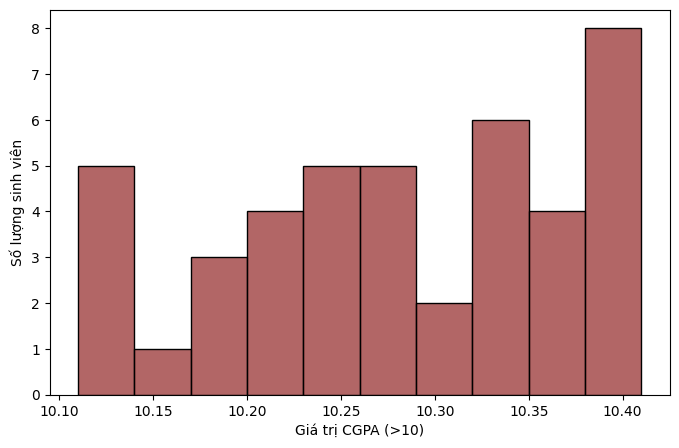

In [ ]:
# Các giá trị CGPA bị lỗi
plt.figure(figsize=(8, 5))
error_data = df[df['CGPA'] > 10]
if len(error_data) > 0:
    sns.histplot(error_data['CGPA'], bins=10, color='#993333', kde=False)
    plt.xlabel('Giá trị CGPA (>10)')
    plt.ylabel('Số lượng sinh viên')
else:
    plt.text(0.5, 0.5, "Ko có dữ liệu lỗi")
plt.show()

In [ ]:
a = (df['CGPA']< 5)       # => có 9
print(a.value_counts())

b = (df['CGPA'] > 10)     # => có 43
print(b.value_counts())

CGPA
False    28011
True         9
Name: count, dtype: int64
CGPA
False    27977
True        43
Name: count, dtype: int64


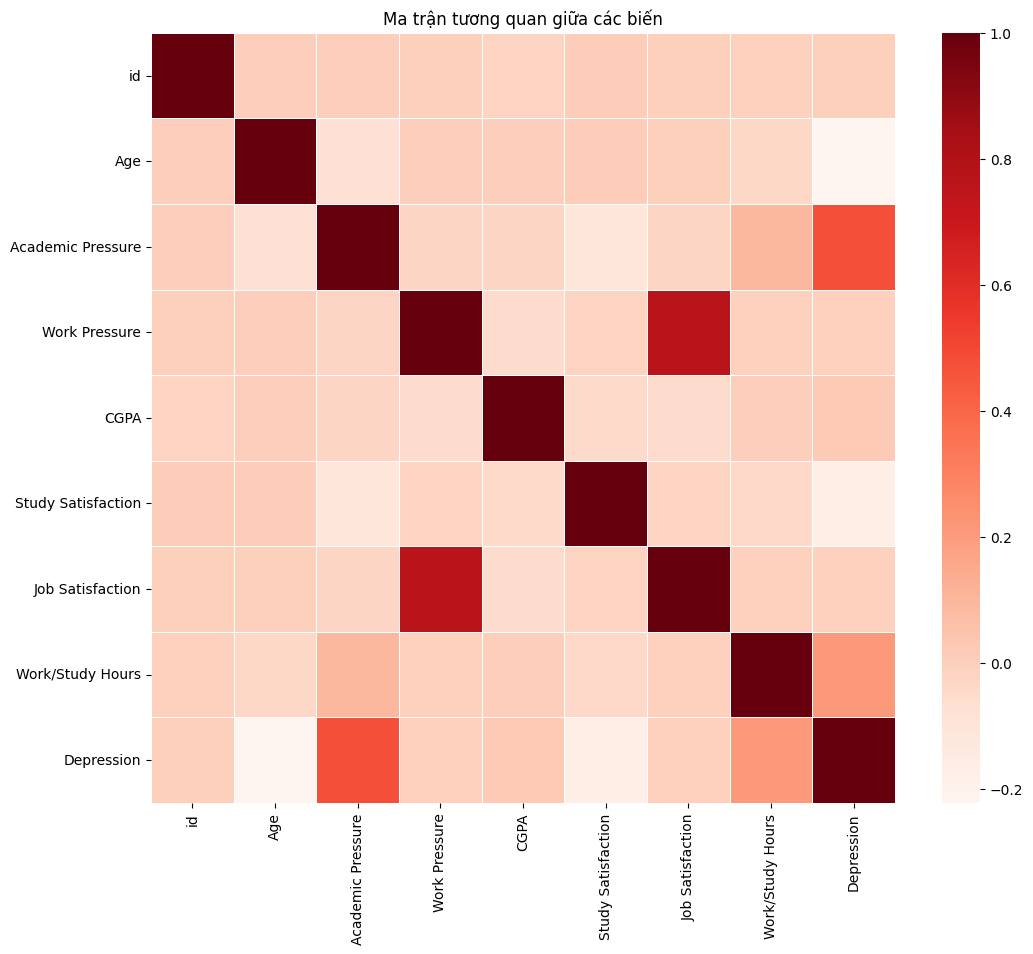

/tmp/ipython-input-3328181038.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y='Academic Pressure', data=df, palette='Set3')


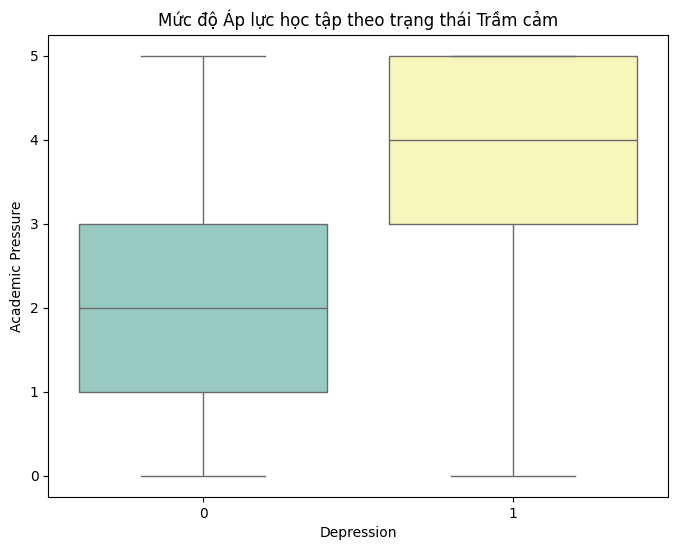

In [ ]:
# 1. Ma trận tương quan (Correlation Matrix)
# Giúp phát hiện biến nào tương quan mạnh với Depression
plt.figure(figsize=(12, 10))
# Chỉ lấy các cột số để vẽ correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='Reds', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến')
plt.show()

# 2. Quan hệ giữa Áp lực học tập và Trầm cảm
plt.figure(figsize=(8, 6))
sns.boxplot(x='Depression', y='Academic Pressure', data=df, palette='Set3')
plt.title('Mức độ Áp lực học tập theo trạng thái Trầm cảm')
plt.show()
# Nhận xét: Nếu boxplot của nhóm Depression=1 cao hơn, nghĩa là áp lực học tập càng cao càng dễ trầm cảm.

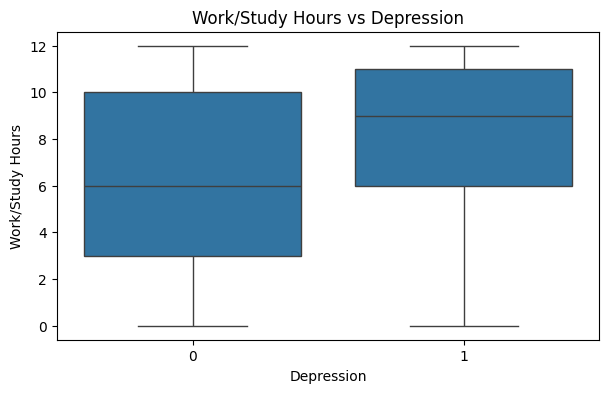

In [ ]:
# Work/Study Hours vs Depression
# Kiểm tra thời gian học/làm việc có ảnh hưởng đến trầm cảm không
plt.figure(figsize=(7,4))
sns.boxplot(x='Depression', y='Work/Study Hours', data=df)
plt.title('Work/Study Hours vs Depression')
plt.xlabel('Depression')
plt.ylabel('Work/Study Hours')
plt.show()

## Count plot

### Gender vs Depression

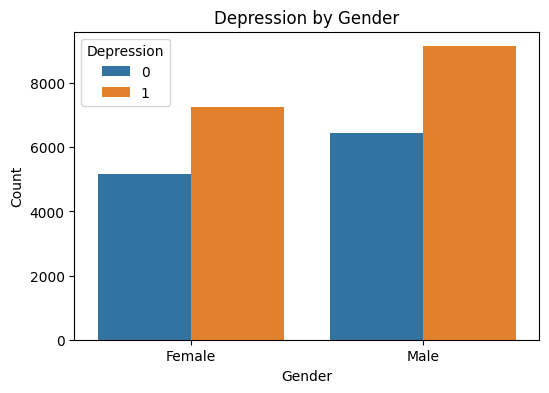

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Depression', data=df)
plt.title('Depression by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Sleep Duration vs Depression

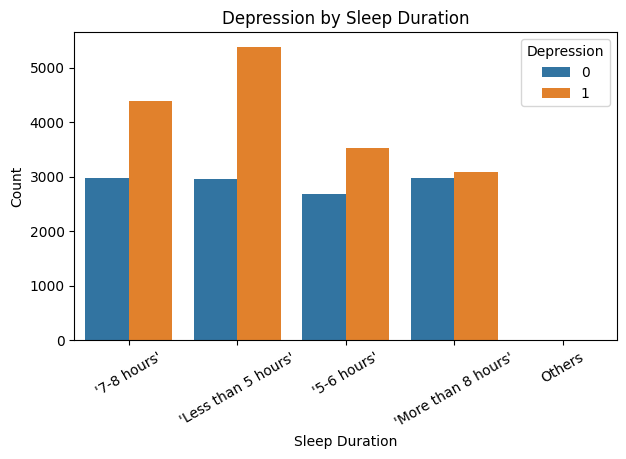

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='Sleep Duration', hue='Depression', data=df)
plt.title('Depression by Sleep Duration')
plt.xticks(rotation=30)
plt.xlabel('Sleep Duration')
plt.ylabel('Count')
plt.show()

Những nhóm có thời gian ngủ ngắn (less than 5 hours) hoặc dài (7-8 hours) có xu hướng có tỷ lệ trầm cảm cao hơn so với nhóm ngủ 5-6 giờ hoặc hơn 8h.

### Suicidal Thoughts vs Depression

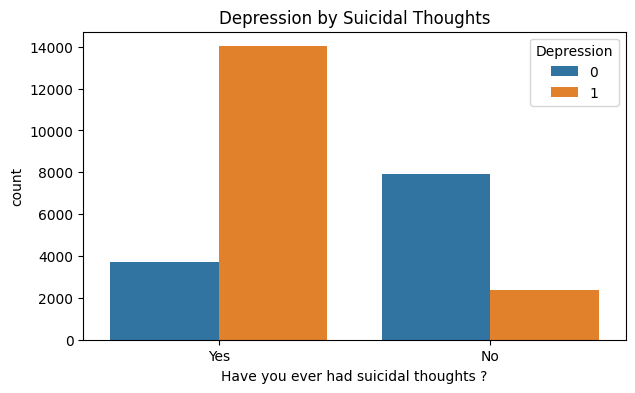

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(
    x='Have you ever had suicidal thoughts ?',
    hue='Depression',
    data=df
)
plt.title('Depression by Suicidal Thoughts')
plt.show()

## Phân phối dl

<Axes: xlabel='Age', ylabel='Count'>

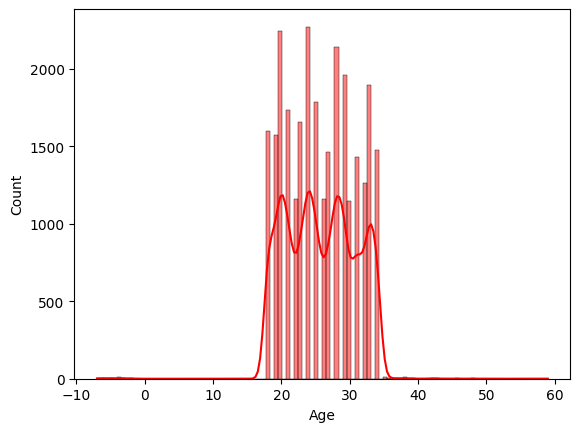

In [ ]:
sns.histplot(df['Age'], kde=True, color='red')

<Axes: xlabel='CGPA', ylabel='Count'>

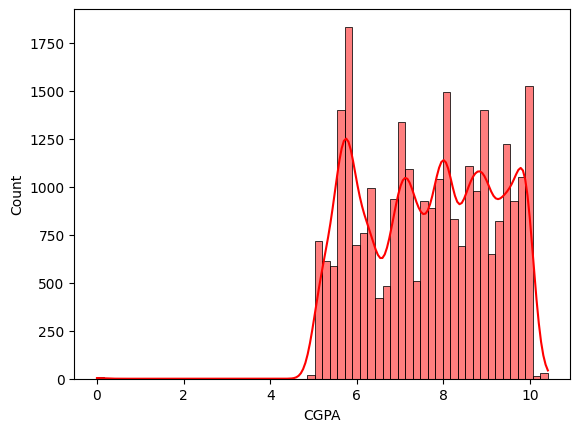

In [ ]:
sns.histplot(df['CGPA'], kde=True, color='red')

## Biến mục tiêu

In [ ]:
df['Depression'].value_counts()

,count
Depression,
1,16406
0,11614


/tmp/ipython-input-379165801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


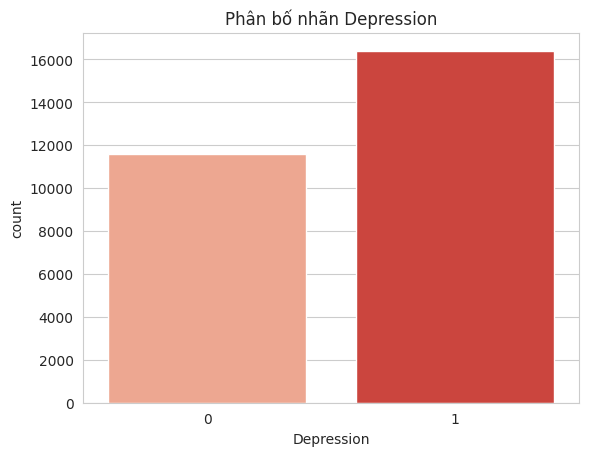

In [ ]:
sns.set_style("whitegrid")

sns.countplot(
    x='Depression',
    data=df,
    palette='Reds'
)
plt.title("Phân bố nhãn Depression")
plt.show()

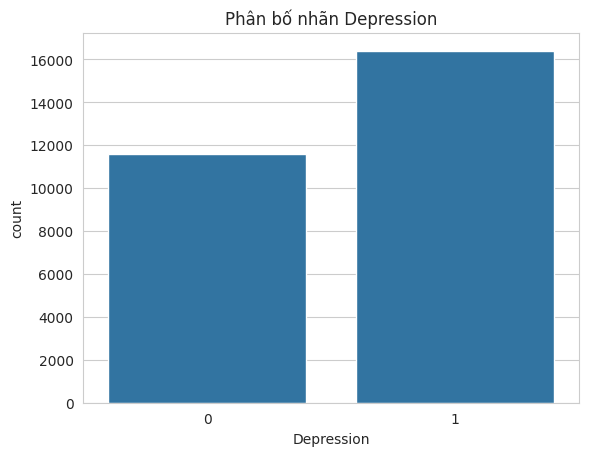

In [ ]:
sns.countplot(x='Depression', data=df)
plt.title("Phân bố nhãn Depression")
plt.show()

=> Số lượng sinh viên bị trầm cảm (1) nhiều hơn không trầm cảm (0)

Mức lệch không quá nghiêm trọng nhưng nên xử lý imbalance → SMOTE

# Ý NGHĨA CÁC BIẾN

In [ ]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

| Tên biến | Ý nghĩa |
|---------|---------|
| id | Mã định danh duy nhất của mỗi sinh viên. |
| Gender | Giới tính của sinh viên. |
| Age | Tuổi của sinh viên. |
| City | Thành phố nơi sinh viên sinh sống/học tập. |
| Profession | Nghề nghiệp hiện tại của sinh viên. |
| Academic Pressure | Mức độ áp lực học tập. |
| Work Pressure | Mức độ áp lực công việc. |
| CGPA | Điểm trung bình tích lũy  |
| Study Satisfaction | Mức độ hài lòng với việc học tập. |
| Job Satisfaction | Mức độ hài lòng với công việc. |
| Sleep Duration | Thời lượng giấc ngủ trung bình. |
| Dietary Habits | Thói quen ăn uống. |
| Degree | Bậc học/Trình độ học vấn. |
| Have you ever had suicidal thoughts ? | Từng có ý nghĩ tự tử hay chưa. |
| Work/Study Hours | Số giờ làm việc/học tập mỗi ngày. |
| Financial Stress | Mức độ căng thẳng về tài chính. |
| Family History of Mental Illness | Tiền sử gia đình có bệnh tâm thần. |
| Depression | Trạng thái trầm cảm (biến mục tiêu). |


# TIỀN XỬ LÝ =)))

In [ ]:
df.shape

(28020, 18)

In [ ]:
# Kiểm tra and xóa dòng trùng lặp
print("Số dòng trùng lặp là:", df.duplicated().sum())
df = df.drop_duplicates()
print("Còn lại:", len(df), "dòng")

Số dòng trùng lặp là: 42
Còn lại: 27978 dòng


## Xử lý missing values

In [ ]:
# Xác định numeric_cols & categorical_cols
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(numeric_cols)
print(categorical_cols)

Index(['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Depression'],
      dtype='object')
Index(['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits',
       'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress',
       'Family History of Mental Illness'],
      dtype='object')


In [ ]:
# Numeric → điền median
columns_to_check = ['Academic Pressure', 'Work Pressure', 'Study Satisfaction']
print("Xử lý các cột bị thiếu bằng Median")
processed_columns_info = {}

for col in columns_to_check:
    missing_count_before = df[col].isnull().sum()     # kt số lượng gt thiếu ban đầu

    if missing_count_before > 0:
        median_value = df[col].median()   # tính median

        df[col] = df[col].fillna(median_value)    # điền gt thiếu = median

        processed_columns_info[col] = {
            'Điền thành công': True,
            'Số lượng đã điền': missing_count_before,
            'Median đã dùng': median_value
        }

        print(f"{col}: Đã điền {missing_count_before} giá trị median = {median_value}")
    else:
        processed_columns_info[col] = {
            'Điền thành công': False,
            'Số lượng đã điền': 0
        }
        print(f" {col}: Không có giá trị thiếu.")

Xử lý các cột bị thiếu bằng Median
Academic Pressure: Đã điền 2 giá trị median = 3.0
Work Pressure: Đã điền 3 giá trị median = 0.0
Study Satisfaction: Đã điền 1 giá trị median = 3.0


In [ ]:
print("Kiểm tra NaN còn lại")
for col in columns_to_check:
    info = processed_columns_info[col]

    missing_count_after = df[col].isnull().sum()

    if info['Điền thành công']:
        if missing_count_after == 0:    # kt xem NaN đã được xử lý hết chưa =)))
            median_used = info['Median đã dùng']
            count_filled = info['Số lượng đã điền']

            print(f"- {col}:")
            print(f"Tổng số đã điền: {count_filled} ")
            print(f"NaN còn lại: {missing_count_after}")
        else:
            print(f" Lỗi {col}: Vẫn còn {missing_count_after} giá trị NaN sau khi điền Median.")
    else:
        print(f"{col}: {missing_count_after}")

Kiểm tra NaN còn lại
- Academic Pressure:
Tổng số đã điền: 2 
NaN còn lại: 0
- Work Pressure:
Tổng số đã điền: 3 
NaN còn lại: 0
- Study Satisfaction:
Tổng số đã điền: 1 
NaN còn lại: 0


## Xử lý outliers

##### Age

In [ ]:
df['Age'].value_counts().sort_index(ascending=True)

,count
Age,
-7.0,3
-6.0,6
-5.0,4
-4.0,8
-3.0,3
-2.0,4
18.0,1590
19.0,1566
20.0,2239


In [ ]:
# xóa tuổi âm
print("Age < 0:", (df['Age'] < 0).sum(), "dòng")
df = df[df['Age'] >= 0]
print("Còn lại:",len(df), "dòng")

Age < 0: 28 dòng
Còn lại: 27950 dòng


##### GPA

In [ ]:
df['CGPA'].value_counts().sort_index(ascending=True)

,count
CGPA,
0.00,9
5.03,17
5.06,15
5.08,95
5.09,20
...,...
10.37,1
10.38,1
10.39,2


In [ ]:
# Xóa CGPA > 10
print("CGPA > 10:", (df['CGPA'] > 10).sum(), "dòng")
df = df[df['CGPA'] <= 10]
print("Còn lại:",len(df),"dòng")

CGPA > 10: 43 dòng
Còn lại: 27907 dòng


In [ ]:
df_before = df.copy()

In [ ]:
Q1 = df['CGPA'].quantile(0.25)
Q3 = df['CGPA'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['CGPA'] >= lower_bound) & (df['CGPA'] <= upper_bound)]

print("Trước:", len(df_before))
print("Sau:", len(df))

Trước: 27907
Sau: 27898


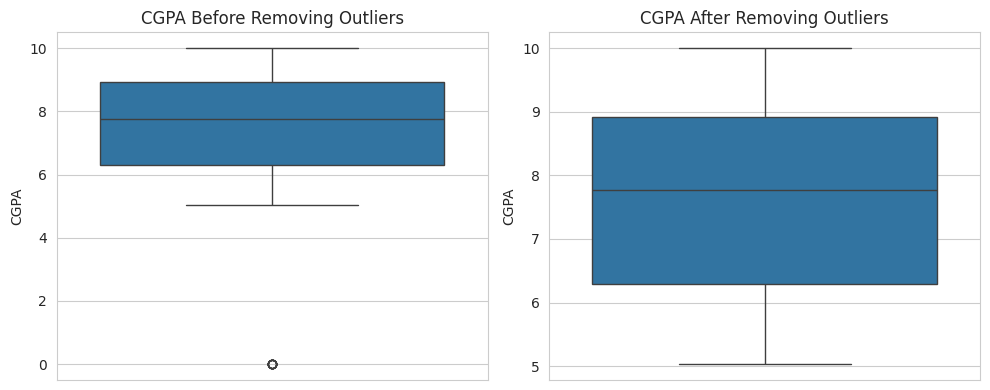

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df_before['CGPA'])
plt.title('CGPA Before Removing Outliers')

plt.subplot(1,2,2)
sns.boxplot(y=df['CGPA'])
plt.title('CGPA After Removing Outliers')

plt.tight_layout()
plt.show()

In [ ]:
df[df['Work/Study Hours'] == 0][['Depression']].value_counts()

,count
Depression,
0,1095
1,604


## Xử lý dữ liệu

In [ ]:
df.shape

(27898, 18)

#####  id => biến này bỏ nè

In [ ]:
# Xóa biến không cần thiết
df = df.drop(columns=['id'])
print(df.columns)
print(df.shape)

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')
(27898, 17)


#####  Work Pressure => XÓA biến này nhé huhum

In [ ]:
df['Work Pressure'].value_counts()

,count
Work Pressure,
0.0,27898


In [ ]:
print(df['Work Pressure'].nunique())
print(df['Work Pressure'].var())

1
0.0


- Dù trầm cảm nhiều hay ít, Work Pressure vẫn không phân biệt được, vì nó chỉ có 1 giá trị
- Do đó không có phương sai và không cung cấp thông tin cho mô hình. Biến này được loại bỏ khỏi tập dữ liệu

In [ ]:
df = df.drop(columns=['Work Pressure'])
print(df.columns)
print(df.shape)

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')
(27898, 16)


#####  Job Satisfaction => XÓA biến

In [ ]:
df['Job Satisfaction'].value_counts()

,count
Job Satisfaction,
0.0,27896
2.0,1
3.0,1


có mỗi 3 gt mà 0 chiếm nhiều v => gây nhiều => xóa đi...

In [ ]:
df = df.drop(columns=['Job Satisfaction'])
print(df.columns)
print(df.shape)

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')
(27898, 15)


#####  Academic Pressure => XÓA DÒNG = 0

In [ ]:
df['Academic Pressure'].value_counts()

,count
Academic Pressure,
3.0,7464
5.0,6296
4.0,5156
1.0,4801
2.0,4178
0.0,3


In [ ]:
# xóa dòng = 0.0
print("Xóa Academic Pressure = 0:", (df['Academic Pressure'] == 0).sum())
df = df[df['Academic Pressure'] > 0]
print("Còn lại:", len(df))

Xóa Academic Pressure = 0: 3
Còn lại: 27895


#####  Study Satisfaction => XÓA DÒNG = 0

In [ ]:
df['Study Satisfaction'].value_counts()

,count
Study Satisfaction,
4.0,6360
2.0,5839
3.0,5821
1.0,5452
5.0,4421
0.0,2


In [ ]:
print("Xóa Study Satisfaction = 0:", (df['Study Satisfaction'] == 0).sum())
df = df[df['Study Satisfaction'] > 0]
print("Còn lại:", len(df))

Xóa Study Satisfaction = 0: 2
Còn lại: 27893


#####  Work/Study Hours => GIỮ NGUYÊN

In [ ]:
df['Work/Study Hours'].value_counts()

,count
Work/Study Hours,
10.0,4234
12.0,3171
11.0,2892
8.0,2508
6.0,2247
9.0,2024
7.0,2001
0.0,1697
4.0,1615


#####  Financial Stress => Điền Median

In [ ]:
df['Financial Stress'].value_counts()

,count
Financial Stress,
5.0,6711
4.0,5775
3.0,5221
1.0,5122
2.0,5061
?,3


In [ ]:
df['Financial Stress'] = pd.to_numeric(
    df['Financial Stress'],
    errors='coerce' # gặp gt ko phải số (abc, ?, bla bla...) thì biến dl đó thành NAN
)
median_value = df['Financial Stress'].median()
df['Financial Stress'] = df['Financial Stress'].fillna(median_value)
print(df['Financial Stress'].value_counts())

Financial Stress
5.0    6711
4.0    5775
3.0    5224
1.0    5122
2.0    5061
Name: count, dtype: int64


## Chuẩn hóa chữ, xử lý dữ liệu rác bla bla......

In [ ]:
text_cols = ['City', 'Profession', 'Degree', 'Sleep Duration']
for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace("'", "", regex=False)
        .str.lower()
    )

Khi encode (Label / One-hot) thì lower() tốt hơn title()

#####  City

In [ ]:
df['City'].value_counts()

,count
City,
kalyan,1570
srinagar,1372
hyderabad,1340
vasai-virar,1290
lucknow,1155
thane,1139
ludhiana,1111
agra,1094
surat,1078


In [ ]:
# sửa lỗi chính tả
df['City'] = df['City'].replace({
    'khaziabad': 'ghaziabad',
    'nalyan': 'kalyan'
})
print(df['City'].value_counts())

City
kalyan                1571
srinagar              1372
hyderabad             1340
vasai-virar           1290
lucknow               1155
thane                 1139
ludhiana              1111
agra                  1094
surat                 1078
kolkata               1066
jaipur                1036
patna                 1006
visakhapatnam          969
pune                   967
ahmedabad              949
bhopal                 934
chennai                884
meerut                 824
rajkot                 815
delhi                  768
bangalore              767
ghaziabad              746
mumbai                 700
vadodara               693
varanasi               684
nagpur                 652
indore                 643
kanpur                 609
nashik                 547
faridabad              460
city                     2
harsha                   2
bhavna                   2
saanvi                   2
m.tech                   1
nandini                  1
less delhi             

In [ ]:
# loại bỏ dl rác (tên người, text, bla bla...) gộp vào "Other"
invalid_values = [
    'city','saanvi','bhavna','harsha','nandini','mihir',
    'vaanya','reyansh','nalini','rashi','gaurav','harsh','mira','kibara',
    'm.tech','m.com','me','3.0',
    'less delhi','less than 5 kalyan'
]
df['City'] = df['City'].replace(invalid_values, 'other')
print(df['City'].value_counts())

City
kalyan           1571
srinagar         1372
hyderabad        1340
vasai-virar      1290
lucknow          1155
thane            1139
ludhiana         1111
agra             1094
surat            1078
kolkata          1066
jaipur           1036
patna            1006
visakhapatnam     969
pune              967
ahmedabad         949
bhopal            934
chennai           884
meerut            824
rajkot            815
delhi             768
bangalore         767
ghaziabad         746
mumbai            700
vadodara          693
varanasi          684
nagpur            652
indore            643
kanpur            609
nashik            547
faridabad         460
other              24
Name: count, dtype: int64


In [ ]:
city_to_region = {
    # Northern India
    'srinagar': 'north', 'lucknow': 'north', 'ludhiana': 'north', 'agra': 'north',
    'jaipur': 'north', 'patna': 'north', 'meerut': 'north', 'delhi': 'north',
    'ghaziabad': 'north', 'varanasi': 'north', 'kanpur': 'north', 'faridabad': 'north',

    # Western India
    'kalyan': 'west', 'vasai-virar': 'west', 'thane': 'west', 'surat': 'west',
    'pune': 'west', 'ahmedabad': 'west', 'rajkot': 'west', 'mumbai': 'west',
    'vadodara': 'west', 'nashik': 'west',

    # Southern India
    'hyderabad': 'south', 'visakhapatnam': 'south', 'chennai': 'south',
    'bangalore': 'south',

    # Central India
    'bhopal': 'central', 'nagpur': 'central', 'indore': 'central',

    # Eastern India
    'kolkata': 'east',
}

In [ ]:
# tạo cột region
df['Region'] = df['City'].map(city_to_region).fillna('other')
print(df['Region'].value_counts())

Region
north      10865
west        9749
south       3960
central     2229
east        1066
other         24
Name: count, dtype: int64


In [ ]:
# OHE
df = df.drop(columns=[c for c in df.columns if c.startswith("Region_")], errors='ignore')
region_dummies = pd.get_dummies(df['Region'], prefix='Region', dtype=int)
df = pd.concat([df, region_dummies], axis=1)
print(df.columns)
df.shape

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Region', 'Region_central', 'Region_east', 'Region_north',
       'Region_other', 'Region_south', 'Region_west'],
      dtype='object')


(27893, 22)

In [ ]:
df = df.drop(columns=['City', 'Region'])
print(df.columns)

Index(['Gender', 'Age', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Region_central', 'Region_east', 'Region_north', 'Region_other',
       'Region_south', 'Region_west'],
      dtype='object')


In [ ]:
df.shape

(27893, 20)

#####  Profession

In [ ]:
df['Profession'].value_counts()

,count
Profession,
student,27862
architect,8
teacher,6
digital marketer,3
content writer,2
chef,2
pharmacist,2
doctor,2
entrepreneur,1


 Student chiếm đa số, tí gom lại thành 2 nhóm là "student" và "other" để tránh mất cân = dl

In [ ]:
# gộp các cái còn lại về thành "Other"
profession_counts = df['Profession'].value_counts()
rare_professions = profession_counts[profession_counts < 10].index
df['Profession'] = df['Profession'].replace(rare_professions, 'other')
print(df['Profession'].value_counts())

Profession
student    27862
other         31
Name: count, dtype: int64


In [ ]:
# OHE
df = pd.get_dummies(df, columns=['Profession'], prefix='Profession',
                    drop_first=True, dtype=int)
print(df.columns)

Index(['Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Region_central', 'Region_east', 'Region_north', 'Region_other',
       'Region_south', 'Region_west', 'Profession_student'],
      dtype='object')


In [ ]:
df.shape

(27893, 20)

##### Sleep Duration

In [ ]:
df['Sleep Duration'].value_counts()

,count
Sleep Duration,
less than 5 hours,8304
7-8 hours,7344
5-6 hours,6182
more than 8 hours,6045
others,18


Ngủ <5h rất xấu

Ngủ 7–8h là tốt nhất

Ngủ >8h không chắc tốt hơn 7–8h

In [ ]:
# Gộp giá trị "others" về "less than 5 hours"
df['Sleep Duration'] = df['Sleep Duration'].replace(
    {'others': 'less than 5 hours'}
)
print(df['Sleep Duration'].value_counts())

Sleep Duration
less than 5 hours    8322
7-8 hours            7344
5-6 hours            6182
more than 8 hours    6045
Name: count, dtype: int64


In [ ]:
sleep_map = {
    'less than 5 hours': 0,
    '5-6 hours': 1,
    '7-8 hours': 2,
    'more than 8 hours': 3
}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)
print(df['Sleep Duration'].value_counts())

Sleep Duration
0    8322
2    7344
1    6182
3    6045
Name: count, dtype: int64


Sleep Duration có thứ tự tự nhiên về thời lượng nên được mã hóa ordinal để giữ thông tin mức độ. Việc mã hóa này không giả định rằng ngủ nhiều hơn luôn tốt hơn, mà chỉ phản ánh thứ tự thời gian

#####  Degree

| Tên biến | Ý nghĩa | Nhóm mới
|---------|---------|---------|
|Class 12 | Lớp 12  | Pre-Degree|
|B.Ed  | Bachelor of Education (Cử nhân Sư phạm) |  Undergraduate|    
|B.Com |Bachelor of Commerce (Cử nhân Thương mại)|  Undergraduate|   
|B.Arch | Bachelor of Architecture (Cử nhân Kiến trúc)|  Undergraduate|    
|BCA|Bachelor of Computer Applications (Cử nhân Ứng dụng Máy tính)|Undergraduate|       
|MSc| Master of Science (Thạc sĩ Khoa học)|  Postgraduate|       
|B.Tech| Bachelor of Technology (Cử nhân Công nghệ) |   Undergraduate|    
|MCA | Master of Computer Applications (Thạc sĩ Ứng dụng Máy tính) | Postgraduate|       
|M.Tech  |Master of Technology (Thạc sĩ Công nghệ)|Postgraduate|
|BHM | Cử nhân Quản lý Khách sạn (Bachelor of Hotel Management)| Undergraduate |       
|BSc  |Cử nhân Khoa học (Bachelor of Science) |Undergraduate|        
|M.Ed    |Thạc sĩ Giáo dục (Master of Education)|Postgraduate|     
|B.Pharm  |Cử nhân Dược (Bachelor of Pharmacy)|Undergraduate|    
|M.Com |Thạc sĩ Thương mại (Master of Commerce)|Postgraduate|       
|MBBS |  Doctor of Philosophy (Tiến sĩ) |  Doctorate|    
|BBA |Cử nhân Quản trị Kinh doanh (Bachelor of Business Administration)|Undergraduate|         
|LLB |Cử nhân Luật (Legum Baccalaureus)|Undergraduate|         
|BE |Cử nhân Kỹ thuật (Bachelor of Engineering)|Undergraduate|          
|BA  |Cử nhân Nghệ thuật (Bachelor of Arts)|Undergraduate |         
|M.Pharm |Thạc sĩ Dược (Master of Pharmacy)|Postgraduate|     
|MD  |Tiến sĩ Y khoa (Medicinine Doctor)|Doctorate|         
|MBA |Thạc sĩ Quản trị Kinh doanh (Master of Business Administration)|Postgraduate|         
|MA |Thạc sĩ Nghệ thuật (Master of Arts)|Postgraduate|          
|PhD   |Tiến sĩ (Doctor of Philosophy)|Doctorate|       
|LLM |Thạc sĩ Luật (Legum Magister)|Postgraduate|         
|MHM |Thạc sĩ Quản lý Khách sạn (Master of Hotel Management)|Postgraduate|         
|ME |Thạc sĩ Kỹ thuật (Master of Engineering)|Postgraduate|          
|Others | Các bằng cấp khác. | Others |       

In [ ]:
df['Degree'].value_counts()

,count
Degree,
class 12,6071
b.ed,1867
b.com,1506
b.arch,1478
bca,1433
msc,1191
b.tech,1152
mca,1044
m.tech,1022


In [ ]:
degree_groups = {
    # pre-degree
    'class 12': 'predegree',

    # undergraduate
    'b.ed': 'undergraduate', 'b.com': 'undergraduate', 'b.arch': 'undergraduate',
    'bca': 'undergraduate', 'b.tech': 'undergraduate', 'bhm': 'undergraduate',
    'bsc': 'undergraduate', 'b.pharm': 'undergraduate', 'bba': 'undergraduate',
    'llb': 'undergraduate', 'be': 'undergraduate', 'ba': 'undergraduate',

    # postgraduate
    'msc': 'postgraduate', 'mca': 'postgraduate', 'm.tech': 'postgraduate',
    'm.ed': 'postgraduate', 'm.com': 'postgraduate', 'm.pharm': 'postgraduate',
    'mba': 'postgraduate', 'ma': 'postgraduate', 'llm': 'postgraduate',
    'mhm': 'postgraduate', 'me': 'postgraduate',

    # doctorate
    'phd': 'doctorate',
    'mbbs': 'doctorate',
    'md': 'doctorate',
}

In [ ]:
df['Degree_Group'] = df['Degree'].map(degree_groups)
df['Degree_Group'] = df['Degree_Group'].fillna('other')

In [ ]:
degree_ohe = pd.get_dummies(df['Degree_Group'], prefix='Degree', dtype=int)
df = pd.concat([df, degree_ohe], axis=1)

In [ ]:
df.shape

(27893, 26)

In [ ]:
df.columns

Index(['Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Region_central', 'Region_east', 'Region_north', 'Region_other',
       'Region_south', 'Region_west', 'Profession_student', 'Degree_Group',
       'Degree_doctorate', 'Degree_other', 'Degree_postgraduate',
       'Degree_predegree', 'Degree_undergraduate'],
      dtype='object')

In [ ]:
df.drop(columns=['Degree', 'Degree_Group'], inplace=True)

In [ ]:
df.shape

(27893, 24)

## Encoding categorical features

### OHE

#####  Gender

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,15542
Female,12351


In [ ]:
df= pd.get_dummies(df, columns=['Gender'], prefix='Gender', dtype=int)
print(df.columns)

Index(['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Region_central', 'Region_east', 'Region_north', 'Region_other',
       'Region_south', 'Region_west', 'Profession_student', 'Degree_doctorate',
       'Degree_other', 'Degree_postgraduate', 'Degree_predegree',
       'Degree_undergraduate', 'Gender_Female', 'Gender_Male'],
      dtype='object')


In [ ]:
df.shape

(27893, 25)

### Binary → 0/1

##### Have you ever had suicidal thoughts

#####  Family History of Mental Illness

In [ ]:
print(df['Have you ever had suicidal thoughts ?'].value_counts())
print(df['Family History of Mental Illness'].value_counts())

Have you ever had suicidal thoughts ?
Yes    17649
No     10244
Name: count, dtype: int64
Family History of Mental Illness
No     14392
Yes    13501
Name: count, dtype: int64


In [ ]:
binary_map = {'Yes': 1, 'No': 0}
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map(binary_map)
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map(binary_map)
print(df['Have you ever had suicidal thoughts ?'].value_counts())
print(df['Family History of Mental Illness'].value_counts())

Have you ever had suicidal thoughts ?
1    17649
0    10244
Name: count, dtype: int64
Family History of Mental Illness
0    14392
1    13501
Name: count, dtype: int64


##### Dietary Habits => ORDINAL

In [ ]:
df['Dietary Habits'].value_counts()

,count
Dietary Habits,
Unhealthy,10314
Moderate,9915
Healthy,7652
Others,12


In [ ]:
# gộp other vào moderate
df['Dietary Habits'] = df['Dietary Habits'].replace({
    'Others': 'Moderate'
})
print(df['Dietary Habits'].value_counts())

Dietary Habits
Unhealthy    10314
Moderate      9927
Healthy       7652
Name: count, dtype: int64


In [ ]:
diet_map = {
    'Unhealthy': 0,
    'Moderate': 1,
    'Healthy': 2
}
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)
print(df['Dietary Habits'].value_counts())

Dietary Habits
0    10314
1     9927
2     7652
Name: count, dtype: int64


#####  Depression => BIẾN MỤC TIÊU

In [ ]:
df['Depression'].value_counts()

,count
Depression,
1,16332
0,11561


## Tách feature & label

In [ ]:
X = df.drop(columns=['Depression'])
y = df['Depression']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

## Xử lý imbalance bằng SMOTE (CHỈ TRAIN)

Do dữ liệu mục tiêu bị mất cân bằng giữa hai lớp trầm cảm và không trầm cảm, kỹ thuật SMOTE được áp dụng trên tập huấn luyện nhằm tạo thêm các mẫu tổng hợp cho lớp thiểu số. Việc này giúp mô hình học được ranh giới phân lớp tốt hơn và cải thiện các chỉ số Recall và F1-score.

In [ ]:
X_train.dtypes

,0
Age,float64
Academic Pressure,float64
CGPA,float64
Study Satisfaction,float64
Sleep Duration,int64
Dietary Habits,int64
Have you ever had suicidal thoughts ?,int64
Work/Study Hours,float64
Financial Stress,float64
Family History of Mental Illness,int64


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

## Chuẩn hóa/Normalization

Chuẩn hóa (Normalization/Scaling) là quá trình biến đổi các biến số về cùng thang đo nhằm đảm bảo sự công bằng giữa các đặc trưng trong quá trình học của mô hình, đặc biệt quan trọng với các mô hình dựa trên khoảng cách hoặc tuyến tính như Logistic Regression.

In [ ]:
numeric_cols = [
    'Age',
    'CGPA',
    'Academic Pressure',
    'Study Satisfaction',
    'Work/Study Hours',
    'Financial Stress'
]

### SCALE (cho LR & SVM)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_scale = X_train_sm.copy()
X_val_scale   = X_val.copy()
X_test_scale  = X_test.copy()

scaler = StandardScaler()
scaler.fit(X_train_scale[numeric_cols])

X_train_scale.loc[:, numeric_cols] = scaler.transform(X_train_scale[numeric_cols])
X_val_scale.loc[:, numeric_cols]   = scaler.transform(X_val_scale[numeric_cols])
X_test_scale.loc[:, numeric_cols]  = scaler.transform(X_test_scale[numeric_cols])

### KHÔNG SCALE (cho RF & XGBoost)

In [ ]:
X_train_tree = X_train_sm.copy()
X_val_tree   = X_val.copy()
X_test_tree  = X_test.copy()

# HUẤN LUYỆN MÔ HÌNH

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scale, y_train_sm)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

C=1.0: mặc định, tránh overfitting

class_weight='balanced': xử lý mất cân bằng

max_iter=1000: đảm bảo hội tụ

## Random Forest

n_estimators=300: đủ mạnh, ổn định

max_depth=15: tránh overfitting

class_weight='balanced': xử lý imbalance

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train_tree, y_train_sm)

RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=200,
                       random_state=42)

## XGBoost

learning_rate=0.1: cân bằng tốc độ & hiệu quả

max_depth=6: tránh overfitting

scale_pos_weight: cân bằng lớp

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_tree, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## SVM - Support Vector Machine

kernel='rbf': xử lý phi tuyến

C=1.0: kiểm soát margin

gamma='scale': tự động tối ưu

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_scale, y_train_sm)

SVC(class_weight='balanced', probability=True, random_state=42)

# ĐÁNH GIÁ & SO SÁNH KẾT QUẢ

## Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score
)

models = {
    'Logistic Regression': (lr, X_val_scale),
    'SVM': (svm, X_val_scale),
    'Random Forest': (rf, X_val_tree),
    'XGBoost': (xgb, X_val_tree)
}

results = {}

for name, (model, Xv) in models.items():
    print("="*60)
    print(name.upper())

    # Predict label
    y_pred = model.predict(Xv)

    # Predict probability (cho AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(Xv)[:, 1]
    else:  # SVM
        y_prob = model.decision_function(Xv)

    # Metrics
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    auc  = roc_auc_score(y_val, y_prob)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc
    }
    print(f"Accuracy : {acc}")
    print(f"Precision: {prec}")
    print(f"Recall   : {rec}")
    print(f"F1 Score : {f1}\n")
    print(classification_report(y_val, y_pred))
    print(f"AUC: {auc}")

LOGISTIC REGRESSION
Accuracy : 0.8432122370936902
Precision: 0.8576555023923444
Recall   : 0.8779591836734694
F1 Score : 0.8676885841064945

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1734
           1       0.86      0.88      0.87      2450

    accuracy                           0.84      4184
   macro avg       0.84      0.84      0.84      4184
weighted avg       0.84      0.84      0.84      4184

AUC: 0.9154129887249017
SVM
Accuracy : 0.8413001912045889
Precision: 0.8552108194112967
Recall   : 0.8775510204081632
F1 Score : 0.8662369057211926

              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1734
           1       0.86      0.88      0.87      2450

    accuracy                           0.84      4184
   macro avg       0.84      0.83      0.84      4184
weighted avg       0.84      0.84      0.84      4184

AUC: 0.9103573193983476
RANDOM FOREST
Accuracy : 0.83675

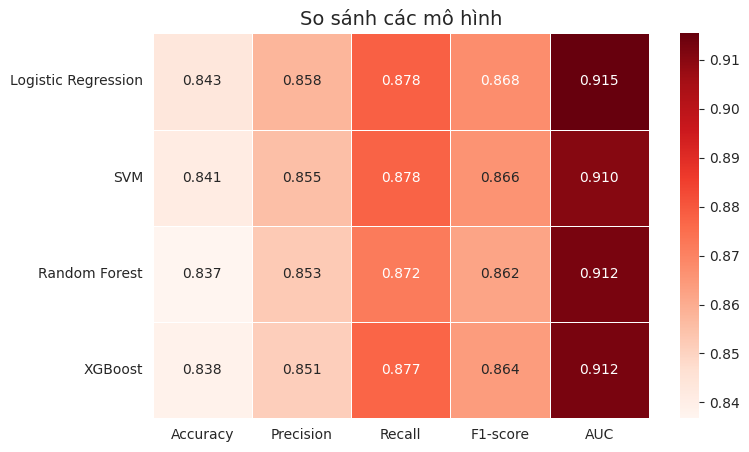

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_metrics = pd.DataFrame(results).T

plt.figure(figsize=(8,5))
sns.heatmap(
    df_metrics,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    linewidths=0.5,
    cbar=True
)

plt.title("So sánh các mô hình", fontsize=14)
plt.yticks(rotation=0)
plt.show()


In [ ]:
result_df = pd.DataFrame(results).T
result_df.style\
    .background_gradient(cmap="Reds", subset=["Accuracy","Precision", "Recall","F1-score","AUC"])\
    .format("{:.3f}")

,Accuracy,Precision,Recall,F1-score,AUC
Logistic Regression,0.843,0.858,0.878,0.868,0.915
SVM,0.841,0.855,0.878,0.866,0.910
Random Forest,0.837,0.853,0.872,0.862,0.912
XGBoost,0.838,0.851,0.877,0.864,0.912


## ROC – AUC

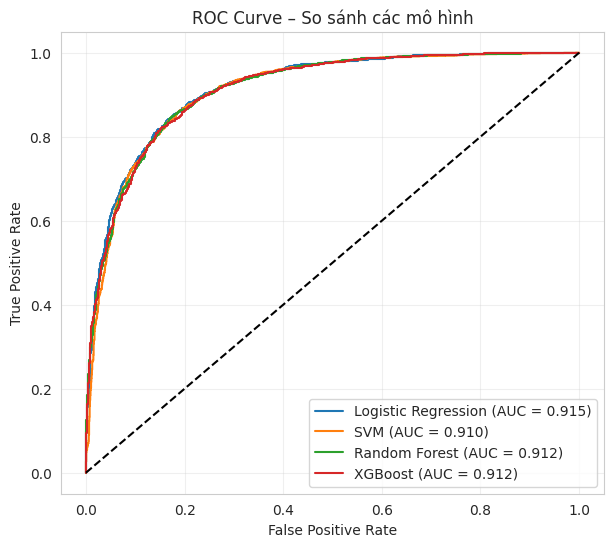

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for name, (model, Xv) in models.items():
    y_prob = model.predict_proba(Xv)[:,1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – So sánh các mô hình")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## CONFUSION MATRIX

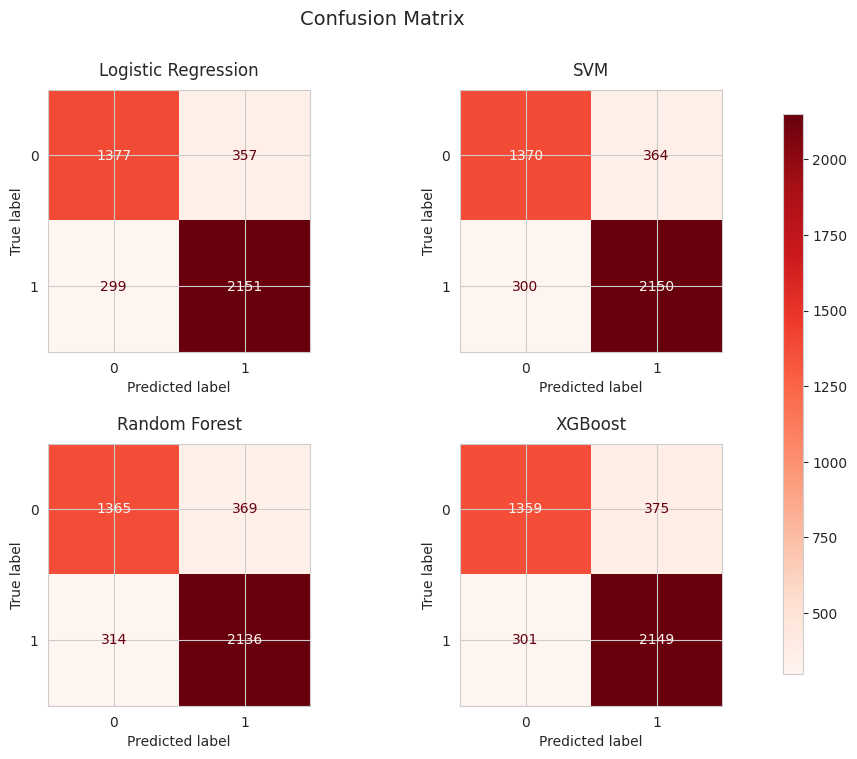

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    gridspec_kw={'right': 0.88}
)
axes = axes.flatten()

for ax, (name, (model, Xv)) in zip(axes, models.items()):
    y_pred = model.predict(Xv)
    cm = confusion_matrix(y_val, y_pred)

    disp = ConfusionMatrixDisplay(cm, display_labels=['0', '1'])
    disp.plot(ax=ax, cmap='Reds', colorbar=False)
    ax.set_title(name, pad=10)

fig.subplots_adjust(hspace=0.35)

im = axes[0].images[0]
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
fig.suptitle("Confusion Matrix", fontsize=14, y=0.98)
plt.show()

## PRECISION–RECALL CURVE

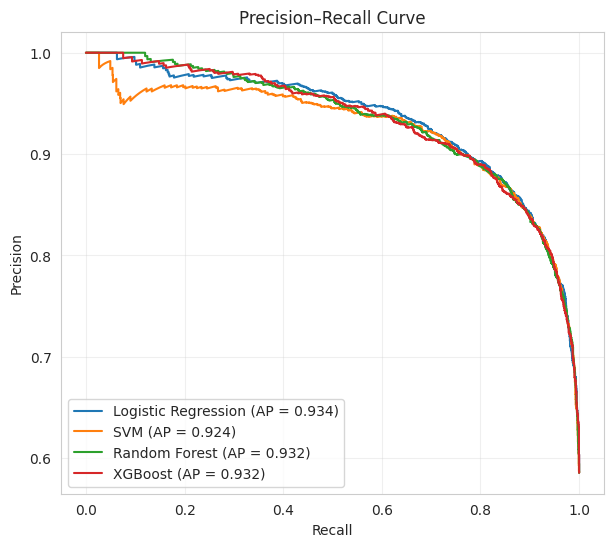

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

for name, (model, Xv) in models.items():
    y_prob = model.predict_proba(Xv)[:,1]
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    ap = average_precision_score(y_val, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Chọn mô hình tốt nhất

Chọn Logistic Regression vì AUC cao, Recall tốt, mô hình đơn giản

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_test_pred = lr.predict(X_test_scale)
y_test_prob = lr.predict_proba(X_test_scale)[:,1]

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("AUC:", roc_auc_score(y_test, y_test_prob))
print(classification_report(y_test, y_test_pred))

Accuracy: 0.844885277246654
Precision: 0.8615014050582096
Recall: 0.8759183673469387
F1: 0.8686500708358632
AUC: 0.9194981522020573
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1734
           1       0.86      0.88      0.87      2450

    accuracy                           0.84      4184
   macro avg       0.84      0.84      0.84      4184
weighted avg       0.84      0.84      0.84      4184



# TEST DL

IN RA CỘT CỦA X, TỪ NHỮNG BIẾN ĐẦU VÀO VIẾT CHO TỚ HÀM HOẶC CÁI GÌ ĐẤY ĐỂ TEST DỮU LIỆU MỚI

In [ ]:
print("Các cột đầu vào của mô hình:")
print(list(X_train.columns))

Các cột đầu vào của mô hình:
['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Region_central', 'Region_east', 'Region_north', 'Region_other', 'Region_south', 'Region_west', 'Profession_student', 'Degree_doctorate', 'Degree_other', 'Degree_postgraduate', 'Degree_predegree', 'Degree_undergraduate', 'Gender_Female', 'Gender_Male']


In [ ]:
df.columns

Index(['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Region_central', 'Region_east', 'Region_north', 'Region_other',
       'Region_south', 'Region_west', 'Profession_student', 'Degree_doctorate',
       'Degree_other', 'Degree_postgraduate', 'Degree_predegree',
       'Degree_undergraduate', 'Gender_Female', 'Gender_Male'],
      dtype='object')

In [ ]:
feature_cols = X_train.columns.tolist()

In [ ]:
new_person = {
    'Age': 20,
    'Academic Pressure': 4,
    'CGPA': 2.8,
    'Study Satisfaction': 2,
    'Sleep Duration': 0,
    'Dietary Habits': 1,
    'Have you ever had suicidal thoughts ?': 0,
    'Work/Study Hours': 8,
    'Financial Stress': 4,
    'Family History of Mental Illness': 0,

    'Region_central': 0,
    'Region_east': 0,
    'Region_north': 1,
    'Region_other': 0,
    'Region_south': 0,
    'Region_west': 0,

    'Profession_student': 1,

    'Degree_doctorate': 0,
    'Degree_other': 0,
    'Degree_postgraduate': 0,
    'Degree_predegree': 0,
    'Degree_undergraduate': 1,

    'Gender_Female': 1,
    'Gender_Male': 0
}

In [ ]:
df_new = pd.DataFrame([new_person])

In [ ]:
# sx đúng thứ tự cột
df_new = df_new[X_train.columns]
# chuẩn hóa để đưa về cùng thang đo
df_new[numeric_cols] = scaler.transform(df_new[numeric_cols])
# Nhãn dự đoán (0 / 1)
pred = lr.predict(df_new)[0]
# xs trầm cảm
prob = lr.predict_proba(df_new)[0][1]


In [ ]:
print("Dự đoán trầm cảm:", "Có" if pred == 1 else "Không")
print("Xác suất trầm cảm:", round(prob, 3))

Dự đoán trầm cảm: Có
Xác suất trầm cảm: 0.689


### DỰ ĐOÁN TRÊN TẬP TEST VỚI NGƯỠNG MỚI (0.3)

In [ ]:
# Xác suất trầm cảm
y_prob = lr.predict_proba(X_test_scale)[:, 1]

# Áp dụng threshold mới, ví dụ 0.3
threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

# Đánh giá
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix (threshold = 0.3)")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report (threshold = 0.3)")
print(classification_report(y_test, y_pred_custom))

Confusion Matrix (threshold = 0.3)
[[1174  560]
 [ 149 2301]]

Classification Report (threshold = 0.3)
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      1734
           1       0.80      0.94      0.87      2450

    accuracy                           0.83      4184
   macro avg       0.85      0.81      0.82      4184
weighted avg       0.84      0.83      0.83      4184



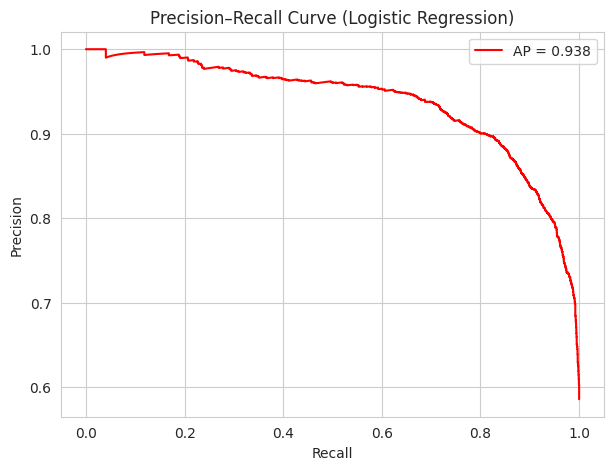

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Xác suất trầm cảm
y_prob = lr.predict_proba(X_test_scale)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision,color='red', label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

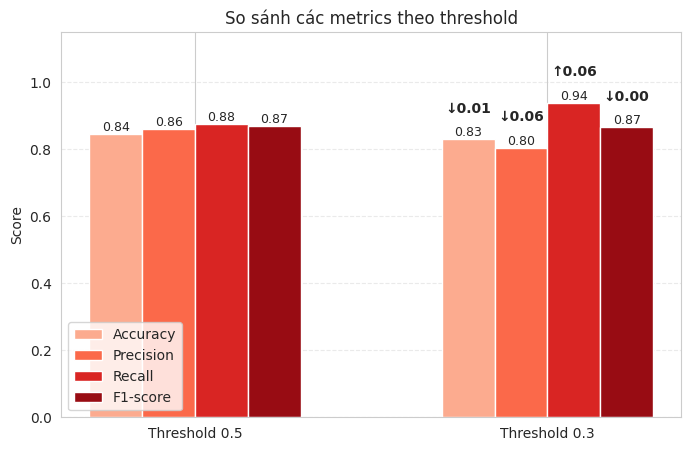

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_prob = lr.predict_proba(X_test_scale)[:, 1]

threshold1 = 0.5
threshold2 = 0.3

y_pred1 = (y_prob >= threshold1).astype(int)
y_pred2 = (y_prob >= threshold2).astype(int)

metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred1), accuracy_score(y_test, y_pred2)],
    'Precision': [precision_score(y_test, y_pred1, zero_division=0), precision_score(y_test, y_pred2, zero_division=0)],
    'Recall': [recall_score(y_test, y_pred1, zero_division=0), recall_score(y_test, y_pred2, zero_division=0)],
    'F1-score': [f1_score(y_test, y_pred1, zero_division=0), f1_score(y_test, y_pred2, zero_division=0)]
}

x = np.arange(len(metrics['Accuracy']))  # 2 threshold
width = 0.15
colors = cm.Reds(np.linspace(0.3, 0.9, len(metrics)))

plt.figure(figsize=(8,5))

for i, (metric, values) in enumerate(metrics.items()):
    bars = plt.bar(
        x + i*width,
        values,
        width,
        label=metric,
        color=colors[i]
    )
    for rect in bars:
        h = rect.get_height()
        plt.text(
            rect.get_x() + rect.get_width()/2,
            h + 0.01,
            f"{h:.2f}",
            ha='center',
            fontsize=9
        )
    delta = values[1] - values[0]
    arrow = "↑" if delta > 0 else "↓"
    plt.text(
        x[1] + i*width,
        values[1] + 0.08,
        f"{arrow}{abs(delta):.2f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
plt.xticks(x + width*1.5, [f'Threshold {threshold1}', f'Threshold {threshold2}'])
plt.ylabel('Score')
plt.title('So sánh các metrics theo threshold')
plt.legend(loc='lower left', frameon=True, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, 1.15)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print("Best threshold theo F1-score:", best_threshold)

Best threshold theo F1-score: 0.38735287989113304


In [ ]:
y_pred_best = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[1286  448]
 [ 215 2235]]
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1734
           1       0.83      0.91      0.87      2450

    accuracy                           0.84      4184
   macro avg       0.84      0.83      0.83      4184
weighted avg       0.84      0.84      0.84      4184



In [ ]:
import pandas as pd
import numpy as np

# Ví dụ new_person
new_person = {
    'Age': 20,
    'Academic Pressure': 4,
    'CGPA': 8.8,
    'Study Satisfaction': 2,
    'Sleep Duration': 0,
    'Dietary Habits': 1,
    'Have you ever had suicidal thoughts ?': 0,
    'Work/Study Hours': 5,
    'Financial Stress': 4,
    'Family History of Mental Illness': 0,
    'Region_central': 0,
    'Region_east': 0,
    'Region_north': 1,
    'Region_other': 0,
    'Region_south': 0,
    'Region_west': 0,
    'Profession_student': 1,
    'Degree_doctorate': 0,
    'Degree_other': 0,
    'Degree_postgraduate': 0,
    'Degree_predegree': 0,
    'Degree_undergraduate': 1,
    'Gender_Female': 1,
    'Gender_Male': 0
}

# Chuyển thành DataFrame
df_new = pd.DataFrame([new_person])

# Đảm bảo đủ các cột giống X_train
for col in X_train.columns:
    if col not in df_new.columns:
        df_new[col] = 0

# Sắp xếp theo đúng thứ tự cột
df_new = df_new[X_train.columns]

# Chuẩn hóa các cột numeric
df_new[numeric_cols] = scaler.transform(df_new[numeric_cols])

# Dự đoán xác suất
prob_new = lr.predict_proba(df_new)[:, 1]

# Dự đoán nhị phân với threshold tối ưu
pred_new = (prob_new >= best_threshold).astype(int)

# In kết quả
print("Xác suất trầm cảm:", round(prob_new[0], 3))
print("Dự đoán trầm cảm:", "Có" if pred_new[0]==1 else "Không")

Xác suất trầm cảm: 0.686
Dự đoán trầm cảm: Có


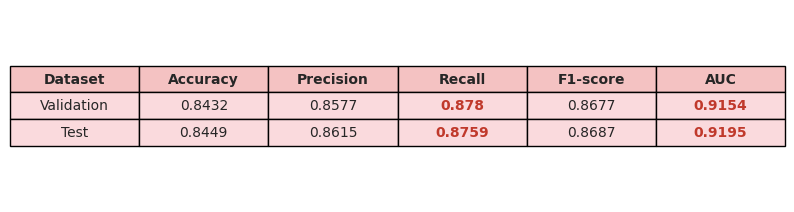

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
results_compare = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'Accuracy': [0.8432, 0.8449],
    'Precision': [0.8577, 0.8615],
    'Recall': [0.8780, 0.8759],
    'F1-score': [0.8677, 0.8687],
    'AUC': [0.9154, 0.9195]
})

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

table = ax.table(
    cellText=results_compare.round(4).values,
    colLabels=results_compare.columns,
    cellLoc='center',
    loc='center'
)

# Màu
PASTEL_RED = '#FADADD'   # nền
DARK_RED   = '#C0392B'   # chỉ số quan trọng
HEADER_BG  = '#F4C2C2'

important_cols = ['Recall', 'AUC']
important_idx = [results_compare.columns.get_loc(c) for c in important_cols]

for (row, col), cell in table.get_celld().items():
    # Header
    if row == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(weight='bold')
    else:
        # Nền pastel cho toàn bảng
        cell.set_facecolor(PASTEL_RED)

        # Nhấn mạnh Recall & AUC
        if col in important_idx:
            cell.set_text_props(color=DARK_RED, weight='bold')

table.scale(1, 1.6)

plt.savefig("val_test_highlight.png", dpi=300, bbox_inches='tight')
plt.show()
